In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import optuna
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

from utils import set_seed
set_seed(42)

 Random seed зафиксирован: 42


# Загрузка данных

In [2]:
df_features = pd.read_csv('data/features.csv')
feature_cols = [col for col in df_features.columns if col not in ['timestamp', 'consumption']]

HORIZON = 24

def create_multistep_targets(series, horizon=24):
    targets = []
    for i in range(len(series) - horizon):
        window = series.iloc[i+1 : i+1+horizon].values
        targets.append(window)
    return np.array(targets)

y_multi = create_multistep_targets(df_features['consumption'], horizon=HORIZON)
X_multi = df_features[feature_cols].iloc[:-HORIZON].copy()
dates = pd.to_datetime(df_features['timestamp']).iloc[:-HORIZON].values

split_idx = int(len(X_multi) * 0.8)

X_train, X_test = X_multi.iloc[:split_idx], X_multi.iloc[split_idx:]
y_train, y_test = y_multi[:split_idx], y_multi[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

print(f"Обучающая выборка: X={X_train.shape}, y={y_train.shape}")
print(f"Тестовая выборка:  X={X_test.shape},  y={y_test.shape}")

Обучающая выборка: X=(6853, 57), y=(6853, 24)
Тестовая выборка:  X=(1714, 57),  y=(1714, 24)


# Настройка XGBoost с Optuna

In [3]:

def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBRegressor(**param)
    model.fit(X_train, y_train, verbose=False)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse


study_xgb = optuna.create_study(direction='minimize', study_name="XGBoost_Optimization")
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print("Лучшие параметры XGBoost:", study_xgb.best_params)



[I 2026-03-03 23:01:13,438] A new study created in memory with name: XGBoost_Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-03 23:01:20,463] Trial 0 finished with value: 159952.75635684605 and parameters: {'n_estimators': 136, 'max_depth': 6, 'learning_rate': 0.04109070522244199, 'subsample': 0.7673994918152112, 'colsample_bytree': 0.8249708044139534, 'reg_alpha': 0.2978879540015891, 'reg_lambda': 0.003163656518257217}. Best is trial 0 with value: 159952.75635684605.
[I 2026-03-03 23:01:40,434] Trial 1 finished with value: 160436.2092822412 and parameters: {'n_estimators': 769, 'max_depth': 4, 'learning_rate': 0.0607860569099114, 'subsample': 0.9767553127149985, 'colsample_bytree': 0.743357715746601, 'reg_alpha': 2.5179804190035027, 'reg_lambda': 0.03615437455140272}. Best is trial 0 with value: 159952.75635684605.
[I 2026-03-03 23:01:57,745] Trial 2 finished with value: 167867.52485895014 and parameters: {'n_estimators': 646, 'max_depth': 4, 'learning_rate': 0.015918083447266702, 'subsample': 0.8280754010933409, 'colsample_bytree': 0.890158234692679, 'reg_alpha': 0.029530773748196515, 'reg_lambd

In [4]:

best_params_xgb = study_xgb.best_params.copy()
best_params_xgb.update({'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1})

model_xgb_opt = xgb.XGBRegressor(**best_params_xgb)
model_xgb_opt.fit(X_train, y_train, verbose=False)

joblib.dump(model_xgb_opt, 'model_weights/xgb_optuna.joblib')


['model_weights/xgb_optuna.joblib']

# Настройка CatBoost с Optuna

In [5]:


def objective_cat(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'loss_function': 'MultiRMSE', # для многошагового прогноза
        'eval_metric': 'MultiRMSE',
        'random_seed': 42,
        'verbose': 0
    }
    
    model = CatBoostRegressor(**param)
    model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=0)
    
    return model.get_best_score()['validation']['MultiRMSE']

study_cat = optuna.create_study(direction='minimize', study_name="CatBoost_Optimization")
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)

print("Лучшие параметры CatBoost:", study_cat.best_params)


[I 2026-03-03 23:12:40,364] A new study created in memory with name: CatBoost_Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

Got unsafe target value = 2.39981e+06 at object #0 of dataset learn
Got unsafe target value = 2.40341e+06 at object #0 of dataset learn
Got unsafe target value = 2.43951e+06 at object #0 of dataset learn
Got unsafe target value = 2.45995e+06 at object #0 of dataset learn
Got unsafe target value = 2.4568e+06 at object #0 of dataset learn
Got unsafe target value = 2.4837e+06 at object #0 of dataset learn
Got unsafe target value = 2.46984e+06 at object #0 of dataset learn
Got unsafe target value = 3.06912e+06 at object #0 of dataset learn
Got unsafe target value = 3.42343e+06 at object #0 of dataset learn
Got unsafe target value = 4.89991e+06 at object #0 of dataset learn
Got unsafe target value = 4.8422e+06 at object #0 of dataset learn
Got unsafe target value = 4.82388e+06 at object #0 of dataset learn
Got unsafe target value = 5.04713e+06 at object #0 of dataset learn
Got unsafe target value = 5.0708e+06 at object #0 of dataset learn
Got unsafe target value = 4.60721e+06 at object #0 o

[I 2026-03-03 23:16:08,515] Trial 0 finished with value: 794245.1926371517 and parameters: {'iterations': 857, 'learning_rate': 0.021913305053793762, 'depth': 8, 'l2_leaf_reg': 6.790836675243511, 'random_strength': 0.0021082505272689627}. Best is trial 0 with value: 794245.1926371517.


Got unsafe target value = 2.39981e+06 at object #0 of dataset learn
Got unsafe target value = 2.40341e+06 at object #0 of dataset learn
Got unsafe target value = 2.43951e+06 at object #0 of dataset learn
Got unsafe target value = 2.45995e+06 at object #0 of dataset learn
Got unsafe target value = 2.4568e+06 at object #0 of dataset learn
Got unsafe target value = 2.4837e+06 at object #0 of dataset learn
Got unsafe target value = 2.46984e+06 at object #0 of dataset learn
Got unsafe target value = 3.06912e+06 at object #0 of dataset learn
Got unsafe target value = 3.42343e+06 at object #0 of dataset learn
Got unsafe target value = 4.89991e+06 at object #0 of dataset learn
Got unsafe target value = 4.8422e+06 at object #0 of dataset learn
Got unsafe target value = 4.82388e+06 at object #0 of dataset learn
Got unsafe target value = 5.04713e+06 at object #0 of dataset learn
Got unsafe target value = 5.0708e+06 at object #0 of dataset learn
Got unsafe target value = 4.60721e+06 at object #0 o

...

[I 2026-03-03 23:35:19,919] Trial 27 finished with value: 709728.613086896 and parameters: {'iterations': 620, 'learning_rate': 0.11627995728153795, 'depth': 7, 'l2_leaf_reg': 1.8156268247604537, 'random_strength': 0.019838800655440046}. Best is trial 10 with value: 684780.8150775611.


Got unsafe target value = 2.39981e+06 at object #0 of dataset learn
Got unsafe target value = 2.40341e+06 at object #0 of dataset learn
Got unsafe target value = 2.43951e+06 at object #0 of dataset learn
Got unsafe target value = 2.45995e+06 at object #0 of dataset learn
Got unsafe target value = 2.4568e+06 at object #0 of dataset learn
Got unsafe target value = 2.4837e+06 at object #0 of dataset learn
Got unsafe target value = 2.46984e+06 at object #0 of dataset learn
Got unsafe target value = 3.06912e+06 at object #0 of dataset learn
Got unsafe target value = 3.42343e+06 at object #0 of dataset learn
Got unsafe target value = 4.89991e+06 at object #0 of dataset learn
Got unsafe target value = 4.8422e+06 at object #0 of dataset learn
Got unsafe target value = 4.82388e+06 at object #0 of dataset learn
Got unsafe target value = 5.04713e+06 at object #0 of dataset learn
Got unsafe target value = 5.0708e+06 at object #0 of dataset learn
Got unsafe target value = 4.60721e+06 at object #0 o

[I 2026-03-03 23:36:24,265] Trial 28 finished with value: 734439.6648519255 and parameters: {'iterations': 512, 'learning_rate': 0.0773702230401825, 'depth': 7, 'l2_leaf_reg': 1.6606022415028652, 'random_strength': 0.0073994384977477175}. Best is trial 10 with value: 684780.8150775611.


Got unsafe target value = 2.39981e+06 at object #0 of dataset learn
Got unsafe target value = 2.40341e+06 at object #0 of dataset learn
Got unsafe target value = 2.43951e+06 at object #0 of dataset learn
Got unsafe target value = 2.45995e+06 at object #0 of dataset learn
Got unsafe target value = 2.4568e+06 at object #0 of dataset learn
Got unsafe target value = 2.4837e+06 at object #0 of dataset learn
Got unsafe target value = 2.46984e+06 at object #0 of dataset learn
Got unsafe target value = 3.06912e+06 at object #0 of dataset learn
Got unsafe target value = 3.42343e+06 at object #0 of dataset learn
Got unsafe target value = 4.89991e+06 at object #0 of dataset learn
Got unsafe target value = 4.8422e+06 at object #0 of dataset learn
Got unsafe target value = 4.82388e+06 at object #0 of dataset learn
Got unsafe target value = 5.04713e+06 at object #0 of dataset learn
Got unsafe target value = 5.0708e+06 at object #0 of dataset learn
Got unsafe target value = 4.60721e+06 at object #0 o

[I 2026-03-03 23:39:37,301] Trial 29 finished with value: 769193.0790024422 and parameters: {'iterations': 788, 'learning_rate': 0.023800158395686638, 'depth': 8, 'l2_leaf_reg': 2.759522628660576, 'random_strength': 0.002197350779767552}. Best is trial 10 with value: 684780.8150775611.
Лучшие параметры CatBoost: {'iterations': 583, 'learning_rate': 0.17811197314967622, 'depth': 5, 'l2_leaf_reg': 3.7042073953046, 'random_strength': 0.561887433686772}


In [6]:

best_params_cat = study_cat.best_params.copy()
best_params_cat.update({'loss_function': 'MultiRMSE', 'eval_metric': 'MultiRMSE', 'random_seed': 42, 'verbose': 0})

model_cat_opt = CatBoostRegressor(**best_params_cat)
model_cat_opt.fit(X_train, y_train)

joblib.dump(model_cat_opt, 'model_weights/catboost_optuna.joblib')


Got unsafe target value = 2.39981e+06 at object #0 of dataset learn
Got unsafe target value = 2.40341e+06 at object #0 of dataset learn
Got unsafe target value = 2.43951e+06 at object #0 of dataset learn
Got unsafe target value = 2.45995e+06 at object #0 of dataset learn
Got unsafe target value = 2.4568e+06 at object #0 of dataset learn
Got unsafe target value = 2.4837e+06 at object #0 of dataset learn
Got unsafe target value = 2.46984e+06 at object #0 of dataset learn
Got unsafe target value = 3.06912e+06 at object #0 of dataset learn
Got unsafe target value = 3.42343e+06 at object #0 of dataset learn
Got unsafe target value = 4.89991e+06 at object #0 of dataset learn
Got unsafe target value = 4.8422e+06 at object #0 of dataset learn
Got unsafe target value = 4.82388e+06 at object #0 of dataset learn
Got unsafe target value = 5.04713e+06 at object #0 of dataset learn
Got unsafe target value = 5.0708e+06 at object #0 of dataset learn
Got unsafe target value = 4.60721e+06 at object #0 o

['model_weights/catboost_optuna.joblib']

# Настройка Random Forest с Optuna

In [7]:


def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = RandomForestRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

study_rf = optuna.create_study(direction='minimize', study_name="RandomForest_Optimization")
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print("Лучшие параметры Random Forest:", study_rf.best_params)



[I 2026-03-03 23:40:01,408] A new study created in memory with name: RandomForest_Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-03 23:40:04,747] Trial 0 finished with value: 173692.64904074775 and parameters: {'n_estimators': 172, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 173692.64904074775.
[I 2026-03-03 23:40:09,440] Trial 1 finished with value: 165348.9981599582 and parameters: {'n_estimators': 212, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 1 with value: 165348.9981599582.
[I 2026-03-03 23:40:12,092] Trial 2 finished with value: 171630.72619647067 and parameters: {'n_estimators': 138, 'max_depth': 12, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 1 with value: 165348.9981599582.
[I 2026-03-03 23:40:15,133] Trial 3 finished with value: 171656.04946483418 and parameters: {'n_estimators': 162, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 1 with value: 165348.9981599582.
[I 2026-03-03 23:40:18,136] Trial 4 finished with value: 164753.66433870775 and parameters: {'n_

In [8]:

best_params_rf = study_rf.best_params.copy()
best_params_rf.update({'random_state': 42, 'n_jobs': -1})

model_rf_opt = RandomForestRegressor(**best_params_rf)
model_rf_opt.fit(X_train, y_train)

joblib.dump(model_rf_opt, 'model_weights/rf_optuna.joblib')

['model_weights/rf_optuna.joblib']

# Итоговое сравнение улучшенных моделей

                Модель   MAE (Вт)  RMSE (Вт)  R2 Score
      XGBoost (Optuna) 107250.538 154119.278     0.975
     CatBoost (Optuna) 103589.807 139780.298     0.980
Random Forest (Optuna) 121362.860 161773.381     0.973


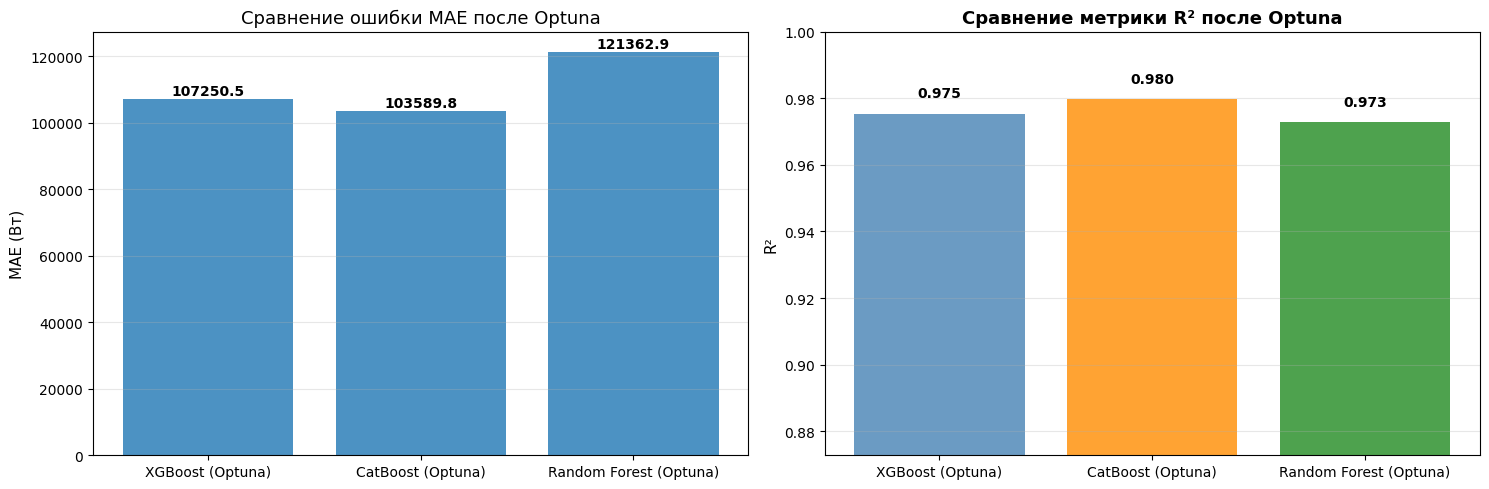

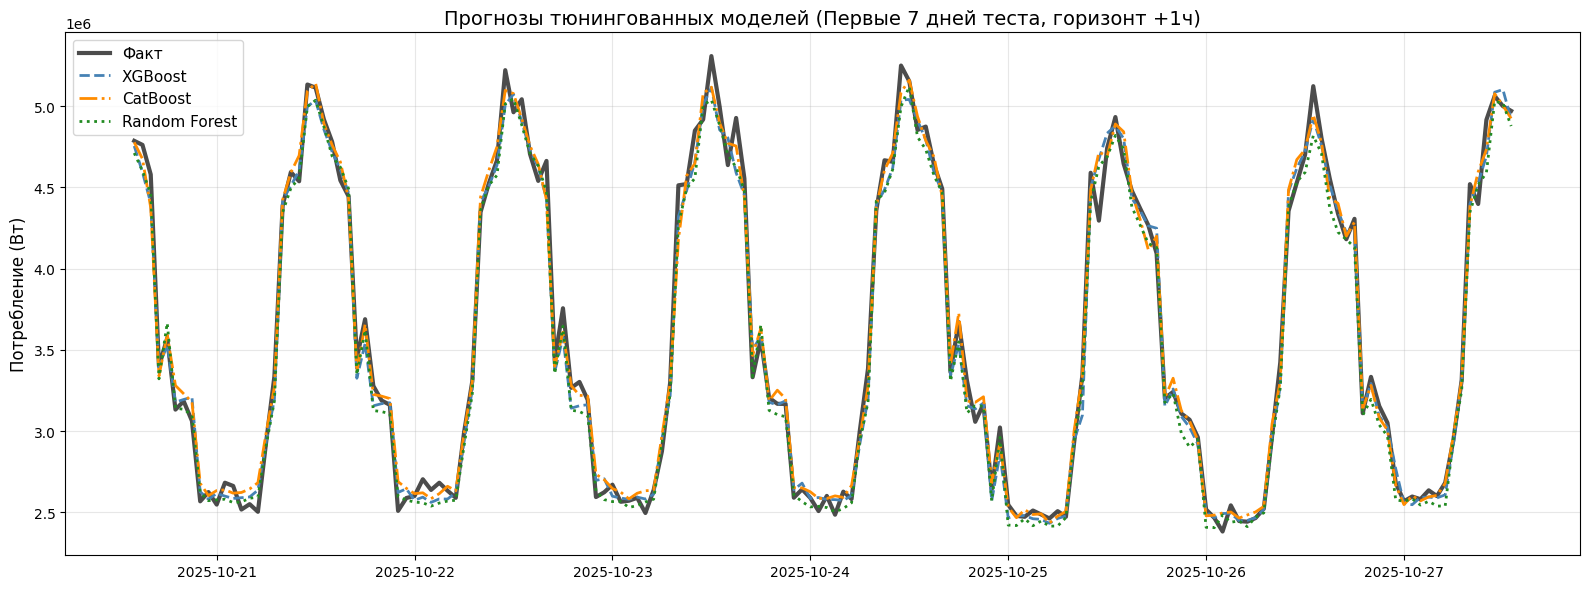

In [9]:


y_pred_xgb = model_xgb_opt.predict(X_test)
y_pred_cat = model_cat_opt.predict(X_test)
y_pred_rf = model_rf_opt.predict(X_test)

models_info = [
    ("XGBoost (Optuna)", y_pred_xgb),
    ("CatBoost (Optuna)", y_pred_cat),
    ("Random Forest (Optuna)", y_pred_rf)
]

metrics_list = []
for name, preds in models_info:
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    metrics_list.append({"Модель": name, "MAE (Вт)": mae, "RMSE (Вт)": rmse, "R2 Score": r2})

df_metrics = pd.DataFrame(metrics_list)
print(df_metrics.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Визуализация 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
model_colors = ['steelblue', 'darkorange', 'forestgreen']

axes[0].bar(df_metrics["Модель"], df_metrics["MAE (Вт)"] ,alpha=0.8)
axes[0].set_title('Сравнение ошибки MAE после Optuna', fontsize=13)
axes[0].set_ylabel('MAE (Вт)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(df_metrics["Модель"], df_metrics["R2 Score"], color=model_colors, alpha=0.8)
axes[1].set_title('Сравнение метрики R² после Optuna', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(bottom=max(0, df_metrics["R2 Score"].min() - 0.1), top=1.0)

for i, v in enumerate(df_metrics["MAE (Вт)"]): axes[0].text(i, v + (v*0.01), f"{v:.1f}", ha='center', fontweight='bold')
for i, v in enumerate(df_metrics["R2 Score"]): axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/07_optuna_models_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Сравнение временных рядов 
n_vis, step_idx = 168, 0
plt.figure(figsize=(16, 6))
plt.plot(dates_test[:n_vis], y_test[:n_vis, step_idx], label='Факт', color='black', linewidth=3, alpha=0.7)
plt.plot(dates_test[:n_vis], y_pred_xgb[:n_vis, step_idx], label='XGBoost', color='steelblue', linewidth=2, linestyle='--')
plt.plot(dates_test[:n_vis], y_pred_cat[:n_vis, step_idx], label='CatBoost', color='darkorange', linewidth=2, linestyle='-.')
plt.plot(dates_test[:n_vis], y_pred_rf[:n_vis, step_idx], label='Random Forest', color='forestgreen', linewidth=2, linestyle=':')

plt.title('Прогнозы тюнингованных моделей (Первые 7 дней теста, горизонт +1ч)', fontsize=14)
plt.ylabel('Потребление (Вт)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/08_optuna_timeseries.png', dpi=150, bbox_inches='tight')

